In [27]:
import pandas as pd
import os
import re
import matplotlib.pyplot as plt

In [38]:
logs_dir = "../log"
log_files = os.listdir(logs_dir)
len(log_files)

86

In [39]:
max_compaction_amount = 0
max_compaction_amount_index = ""

In [40]:
def compaction_info_parser(log_file):
    with open(os.path.join(logs_dir, log_file), "r") as f:        
        params = {}
        param_names = ["insert_proportion", "read_proportion", "update_proportion", "scan_proportion", "delete_proportion", "zipfian_const"]
        for i in range(6):
            match = re.search(r"[-+]?[0-9]*\.?[0-9]+", f.readline())
            if match:
                params[param_names[i]] = float(match.group())
            else:
                raise ValueError(f"Error parsing {param_names[i]}")
        # print("param list:")
        # for key, value in params.items():
        #     print(f"{key}: {value}")
        # print()
             
        f.readline()  # skip the empty line
        try:
            compaction_amount = int(f.readline().split(":")[1].strip())
        except Exception as e:
            print(f"Error parsing compaction amount: {e} at {log_file}")
            return
        f.readline()  # skip the useless line
        
        # print("compaction amount: ", compaction_amount)
        global max_compaction_amount, max_compaction_amount_index
        if max_compaction_amount < compaction_amount:
            max_compaction_amount = compaction_amount
            max_compaction_amount_index = log_file
                    
        compaction_elapsed_time_list = []
        selected_tables_amount = []
        compaction_generated_tables_amount = []
        for i in range(compaction_amount):
            line = f.readline()
            # BUG a wrong spelling of "elapsed_time" in the log file
            match = re.search(r"elaplsed_time:\s*([-+]?[0-9]*\.?[0-9]+)(ms|s)", line)
            if match:
                compaction_elapsed_time_list.append(float(match.group(1)) * (1000 if match.group(2) == "s" else 1))
            else:
                raise ValueError(f"Error parsing compaction elapsed time")
            line = f.readline()
            # TODO so far we ignore specifig index of the tables
            left_side, right_side = line.split(" ==> ")
            pattern = r"\d+@\d+"
            
            left_matches = re.findall(pattern, left_side)
            right_matches = re.findall(pattern, right_side)
            left_count = len(left_matches)
            right_count = len(right_matches)
            
            selected_tables_amount.append(left_count)
            compaction_generated_tables_amount.append(right_count)
        
        plt.figure(figsize=(100, 6))
        plt.plot(compaction_elapsed_time_list, label="compaction_elapsed_time", marker="o")
        plt.xlabel('Compaction Index')
        plt.ylabel('Elapsed Time (ms)')
        plt.title('Compaction Elapsed Time vs. Compaction Index')
        plt.grid(True)
        plt.show()
        plt.savefig(f"compaction_elapsed_time_{log_file}.png")
            

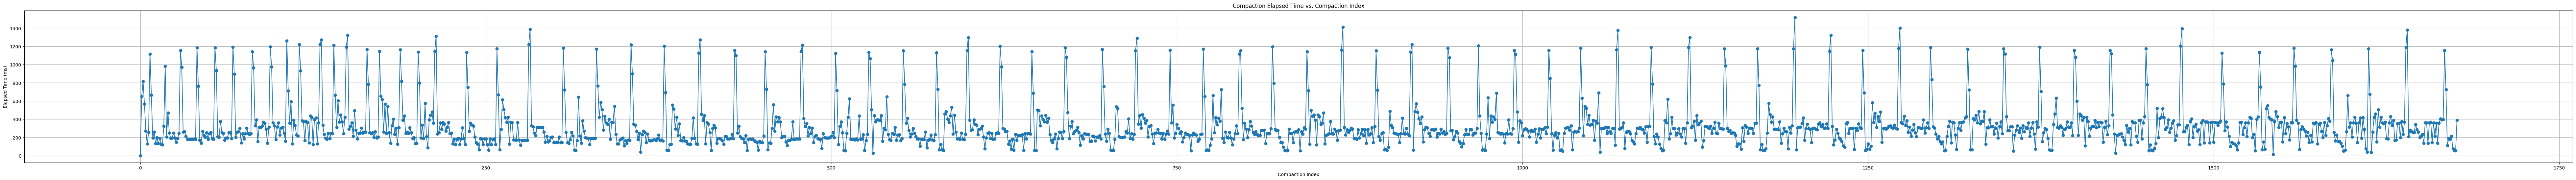

<Figure size 640x480 with 0 Axes>

In [41]:
compaction_info_parser(log_files[0])

In [22]:
for file in log_files:
    compaction_info_parser(file)
print(max_compaction_amount_index, max_compaction_amount)

Error parsing compaction amount: list index out of range at 56.log
6.log 1701


In [29]:
def table_info_parser(log_file):
    with open(os.path.join(logs_dir, log_file), "r") as f:
        index = []
        level = []
        smallest = []
        largest = []
        size = []
        
        line = f.readline()
        while ("table" not in line):
            line = f.readline()
        while ("table" in line):
            pattern = r"table (\d+) level (\d+) range: user(\d+) - user(\d+) size: (\d+)"
            match = re.search(pattern, line)
            if match:
                index.append(int(match.group(1)))
                level.append(int(match.group(2)))
                smallest.append(int(match.group(3)))
                largest.append(int(match.group(4)))
                size.append(int(match.group(5)))
            else:
                pattern2 = r"table (\d+) range: user(\d+) - user(\d+) size: (\d+)"
                match2 = re.search(pattern2, line)
                if match2:
                    index.append(int(match2.group(1)))
                    level.append(0)  # it is level 0 if not written
                    smallest.append(int(match2.group(2)))
                    largest.append(int(match2.group(3)))
                    size.append(int(match2.group(4)))
                else:
                    raise ValueError(f"Error parsing table info")
            line = f.readline()
        return sum(size)
        

In [30]:
max_tables_size_sum = 0
max_tables_size_sum_index = 0
for file in log_files:
    if max_tables_size_sum < table_info_parser(file):
        max_tables_size_sum = table_info_parser(file)
        max_tables_size_sum_index = file
print(max_tables_size_sum_index, max_tables_size_sum)

38.log 1364006473939788071


In [31]:
1364006473939788071 / 1024 / 1024 / 1024

1270330021.101784